In [116]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [117]:
with open("names.txt", "r") as f:
    words = f.read().splitlines()

In [118]:
len(words)

32033

In [119]:
chars = ["."] + sorted(list(set("".join(words))))
stoi, itos = {}, {}
for i, char in enumerate(chars):
    stoi[char] = i
    itos[i] = char

In [120]:
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [ ]:
def build_dataset(words):
    block_size = 3
    X, Y = [], []

    for word in words:
        context = [0] * block_size
        for ch in word + ".":
            idx = stoi[ch]
            X.append(context)
            Y.append(idx)
            context = context[1:] + [idx]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1: n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182515, 3]) torch.Size([182515])
torch.Size([22881, 3]) torch.Size([22881])
torch.Size([22750, 3]) torch.Size([22750])


In [245]:
C = torch.randn(27, 10) # embedding dim = 2
W1 = torch.randn(3 * 10, 200)
b1 = torch.randn(200)
W2 = torch.randn(200, 27)
b2 = torch.randn(27)
parameters = [C, W1, b1, W2, b2]

In [246]:
sum(p.nelement() for p in parameters)

11897

In [247]:
for p in parameters:
    p.requires_grad = True

In [248]:
lri = []
lossi = []
stepi = []

In [252]:
lr = 0.1

for i in range(100000):

    # create minibatch
    ix = torch.randint(0, Xtr.shape[0], (64,))

    # forward pass
    emb = C[Xtr[ix]] # shape = 32 x 3 x 2
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())


2.3784468173980713


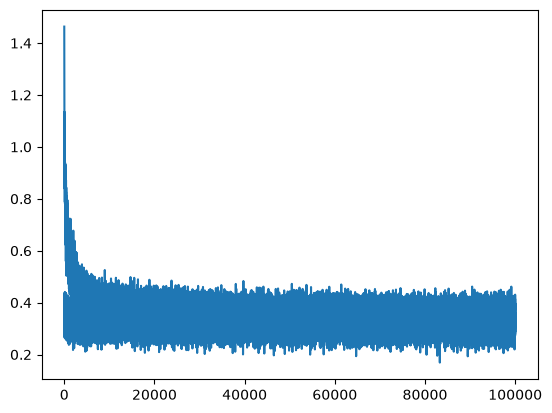

In [253]:
plt.plot(stepi, lossi)

In [254]:
emb = C[Xdev] # shape = 32 x 3 x 2
h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2024, grad_fn=<NllLossBackward0>)

In [ ]:
def sample(context, stoi, itos):
    indices = [stoi[ch] for ch in context]
    emb = C[indices].unsqueeze(0) # shape = 32 x 3 x 2
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    predicted_idx = torch.multinomial(probs, 1, replacement=True)
    predicted_ch = itos[predicted_idx.item()]
    return predicted_ch


def predict_word(stoi, itos):

    output = ["."] * block_size
    output.append(sample(output, stoi, itos))

    while output[-1] != ".":
        output.append(sample(output[-block_size:], stoi, itos))

    return "".join(output[block_size:])



In [313]:
predict_word(stoi, itos)

'pramyah.'